In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats

In [2]:
snapnum = 40

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [11]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType", "SubhaloVmax", "SubhaloVmaxRad", "SubhaloSpin"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

13
<class 'dict'>


In [6]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [7]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [9]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [28]:
sub_spin = np.linalg.norm(subhalos["SubhaloSpin"],axis=1)
sub_sfrs = subhalos["SubhaloSFR"]

In [29]:
len(sub_spin)

18144028

In [30]:
len(sub_sfrs)

18144028

In [38]:
cent_spin1 = sub_spin[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_spin= np.zeros(len(mvir))
cent_spin[halos["GroupFirstSub"]>-1] = cent_spin1
cent_spin = np.log10(cent_spin)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [52]:
logM = 12
dlogM=0.1
mask = (mvir > logM) & (mvir < logM + dlogM)

In [53]:
from scipy import stats

In [54]:
stats.spearmanr(cent_spin[mask], cent_sfrs[mask])

SpearmanrResult(correlation=-0.011637892162984149, pvalue=0.3933645519809239)

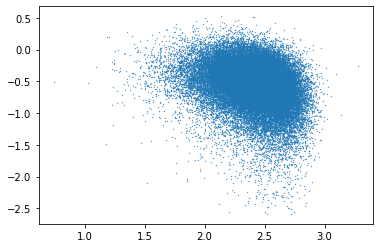

<Figure size 432x288 with 0 Axes>

In [49]:
plt.scatter(cent_spin[mask], cent_sfrs[mask], s=0.1)
plt.show()
plt.clf()

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


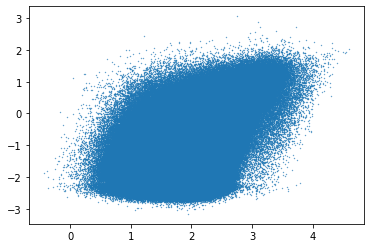

<Figure size 432x288 with 0 Axes>

In [47]:
plt.scatter(np.log10(sub_spin), np.log10(sub_sfrs), s=0.1)
plt.show()
plt.clf()